In [3]:
import pandas as pd
import numpy as np
import scipy as sns
import matplotlib.pyplot as plt

In [109]:
df_Pbh = pd.read_csv("/datasets/QVI_purchase_behaviour.csv")

In [110]:
df_Tbh = pd.read_csv("/datasets/QVI_transaction_data(in).csv")

In [111]:
df_Pbh.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [112]:
df_Pbh["PREMIUM_CUSTOMER"].unique()

array(['Premium', 'Mainstream', 'Budget'], dtype=object)

In [113]:
df_Tbh.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [10]:
df_Pbh.shape

(72637, 3)

In [114]:
df_Pbh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [115]:
df_Pbh.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [116]:
df_Pbh.duplicated().sum()

0

In [117]:
df_Tbh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [118]:
df_Tbh.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [119]:
df_Tbh.duplicated().sum()

1

In [120]:
df_Tbh.shape

(264836, 8)

In [121]:
df_Tbh[df_Tbh.duplicated()]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124845,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [122]:
## i want to remove this line because it is duplicated
df_Tbh = df_Tbh.drop(index = 124845)

In [123]:
df_Tbh.shape

(264835, 8)

In [124]:
## converting the date column
df_Tbh["DATE"] = pd.to_datetime(
   df_Tbh["DATE"],
     origin='1899-12-30',
    unit='D'
)

In [125]:
df_Tbh.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [126]:
## mergin the two tables
df = df_Tbh.merge(
    df_Pbh,
    on = "LYLTY_CARD_NBR",
    how = "left"
)

In [127]:
df.shape

(264835, 10)

In [128]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


detecting outliers

In [129]:
df.describe()

,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264835.000000,2.648350e+05,2.648350e+05,264835.000000,264835.000000,264835.000000
mean,135.080216,1.355496e+05,1.351584e+05,56.583201,1.907308,7.304205
std,76.784306,8.058011e+04,7.813316e+04,32.826692,0.643655,3.083231
min,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,70.000000,7.002100e+04,6.760100e+04,28.000000,2.000000,5.400000
50%,130.000000,1.303580e+05,1.351380e+05,56.000000,2.000000,7.400000
75%,203.000000,2.030945e+05,2.027015e+05,85.000000,2.000000,9.200000
max,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [45]:
df["PROD_QTY"].describe()

count    264835.000000
mean          1.907308
std           0.643655
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

In [130]:
df.sort_values(by="PROD_QTY",ascending=False).head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,OLDER FAMILIES,Premium
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,OLDER FAMILIES,Premium
204366,2018-08-15,223,223025,223075,8,Smiths Crinkle Cut Chips Original 170g,5,14.5,YOUNG FAMILIES,Mainstream
55501,2019-05-17,164,164072,164241,36,Kettle Chilli 175g,5,27.0,OLDER FAMILIES,Mainstream
69815,2018-08-14,257,257208,257019,45,Smiths Thinly Cut Roast Chicken 175g,5,15.0,OLDER FAMILIES,Premium


In [131]:
df.sort_values(by="TOT_SALES",ascending=False).head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,OLDER FAMILIES,Premium
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,OLDER FAMILIES,Premium
171814,2018-08-17,24,24095,20797,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5,RETIREES,Premium
150682,2019-05-20,118,118021,120799,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5,RETIREES,Mainstream
55558,2019-05-14,190,190113,190914,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5,OLDER FAMILIES,Mainstream


In [53]:
## i detect the costumer of lylty_Card_nbr is an outlier it maybe a costumer resseler not regular one
## i preffer to delete it
df = df.drop(index = [69762,69763])

In [132]:
df.describe()

,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264835.000000,2.648350e+05,2.648350e+05,264835.000000,264835.000000,264835.000000
mean,135.080216,1.355496e+05,1.351584e+05,56.583201,1.907308,7.304205
std,76.784306,8.058011e+04,7.813316e+04,32.826692,0.643655,3.083231
min,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,70.000000,7.002100e+04,6.760100e+04,28.000000,2.000000,5.400000
50%,130.000000,1.303580e+05,1.351380e+05,56.000000,2.000000,7.400000
75%,203.000000,2.030945e+05,2.027015e+05,85.000000,2.000000,9.200000
max,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [133]:
df["PROD_NAME"].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

In [138]:
## we see salsa products and we only interested in chips prodects lets remove them
df= df[~df['PROD_NAME'].str.contains('salsa', case=False, na=False)]

In [140]:
df["PROD_NAME"].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'Kettle Original 175g',
       'Red Rock Deli Thai  C

In [149]:
## lets count the number of transactions over time
trans_time = df.groupby("DATE")["TXN_ID"].nunique().reset_index()
trans_time.columns = ["DATE","n_transactions"]
trans_time

,DATE,n_transactions
0,2018-07-01,659
1,2018-07-02,647
2,2018-07-03,669
3,2018-07-04,663
4,2018-07-05,658
...,...,...
359,2019-06-26,656
360,2019-06-27,667
361,2019-06-28,670
362,2019-06-29,700


In [153]:
## there are only 364 dates so we are messing a date
full_dates = pd.date_range(
    start="2018-07-01",
    end="2019-06-30",
    freq="D"
)
calendar = pd.DataFrame({'DATE': full_dates})

In [155]:
daily_txn_full = calendar.merge(
    trans_time,
    on='DATE',
    how='left'
)
daily_txn_full

,DATE,n_transactions
0,2018-07-01,659.0
1,2018-07-02,647.0
2,2018-07-03,669.0
3,2018-07-04,663.0
4,2018-07-05,658.0
...,...,...
360,2019-06-26,656.0
361,2019-06-27,667.0
362,2019-06-28,670.0
363,2019-06-29,700.0


In [162]:
daily_txn_full['n_transactions'] = daily_txn_full['n_transactions'].fillna(0)
daily_txn_full[daily_txn_full["n_transactions"] == 0]

,DATE,n_transactions
177,2018-12-25,0.0


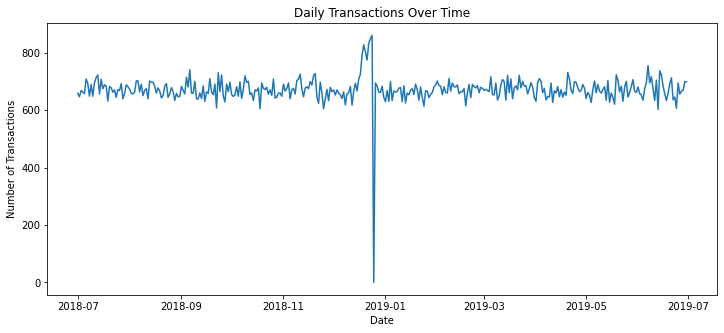

In [163]:
## 2018-12-25 is the messing date
## lets plot transaction over time
plt.figure(figsize=(12,5))
plt.plot(daily_txn_full['DATE'], daily_txn_full['n_transactions'])
plt.title("Daily Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.show()

In [170]:
## i see that there is an increase in purchases in December and a break in late December. Let's zoom in on this
december_txn = daily_txn_full[daily_txn_full["DATE"].dt.month == 12]

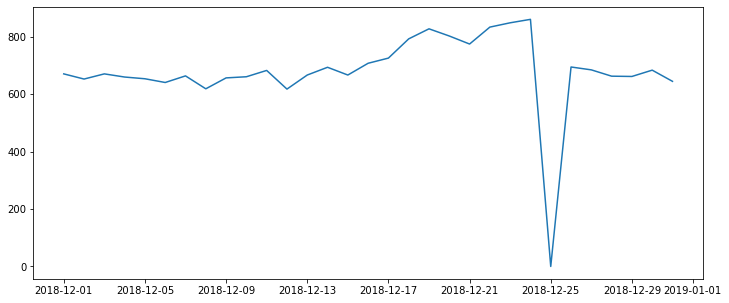

In [173]:
plt.figure(figsize=(12,5))
plt.plot(december_txn["DATE"],december_txn["n_transactions"])

In [ ]:
## We can see that the increase in sales occurs in the lead-up to Christmas and that 
#there are zero sales on Christmas day itself. This is due to shops being closed on Christmas day.

<h1>Feature engineering</h1>

In [177]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [178]:
df['pack_size'] = (
    df['PROD_NAME']
    .str.lower().str.extract(r'(\d+)g')
    .astype(float)
)

In [179]:
df["pack_size"].unique()

array([175., 170., 150., 330., 210., 270., 220., 125., 110., 134., 380.,
       180., 165., 135., 250., 200., 160., 190.,  90.,  70.])

In [189]:
## lets see the number of transactions by pack-size
tr_pa = df.groupby("pack_size")["TXN_ID"].nunique().reset_index()
tr_pa.columns = ["pack_size","n_transactions"]
tr_pa

,pack_size,n_transactions
0,70.0,1507
1,90.0,3008
2,110.0,22378
3,125.0,1454
4,134.0,25093
5,135.0,3257
6,150.0,40174
7,160.0,2970
8,165.0,15290
9,170.0,19969


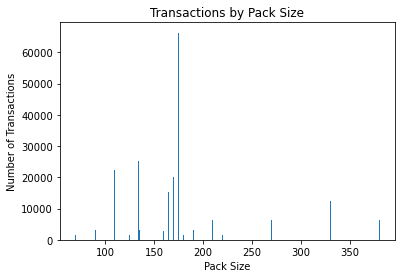

In [194]:
import matplotlib.pyplot as plt

plt.bar(tr_pa["pack_size"], tr_pa["n_transactions"])
plt.xlabel("Pack Size")
plt.ylabel("Number of Transactions")
plt.title("Transactions by Pack Size")
plt.show()

In [195]:
## this looks like normal

In [200]:
d = df.copy

In [211]:
df["brand_name"] = df["PROD_NAME"].str.split(" ").str[0]

In [212]:
df["brand_name"].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'French', 'RRD', 'Tostitos', 'Cheetos',
       'Woolworths', 'Snbts', 'Sunbites'], dtype=object)

In [ ]:
## Some of the brand names look like they are of the same brands - such as RED and 
#RRD, which are both Red Rock Deli chips. Let's combine these together.

In [216]:
df.loc[df["brand_name"] == "RRD", "brand_name"] = "Red"

In [217]:
df["brand_name"].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'French', 'Tostitos', 'Cheetos', 'Woolworths',
       'Snbts', 'Sunbites'], dtype=object)

In [218]:
df["year"] = df["DATE"].dt.year
df['month'] = df['DATE'].dt.month
df['month_year'] = df['DATE'].dt.to_period('M')

In [219]:
df["day"]=df["DATE"].dt.day
df['day_of_week'] = df['DATE'].dt.day_name()

In [221]:
df['customer_segment'] = df['LIFESTAGE'] + " - " + df['PREMIUM_CUSTOMER']

In [222]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,brand_name,year,month,month_year,day,day_of_week,customer_segment
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,175.0,Natural,2018,10,2018-10,17,Wednesday,YOUNG SINGLES/COUPLES - Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget,175.0,CCs,2019,5,2019-05,14,Tuesday,MIDAGE SINGLES/COUPLES - Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,170.0,Smiths,2019,5,2019-05,20,Monday,MIDAGE SINGLES/COUPLES - Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,175.0,Smiths,2018,8,2018-08,17,Friday,MIDAGE SINGLES/COUPLES - Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,150.0,Kettle,2018,8,2018-08,18,Saturday,MIDAGE SINGLES/COUPLES - Budget


In [241]:
## now lets do some data analysis on costumer segments
## lets see who spend more
spending = df.groupby("customer_segment").agg({
    "TOT_SALES":"sum",
})

In [243]:
spending.sort_values(by="TOT_SALES",ascending = False).head(3)

,TOT_SALES
customer_segment,
OLDER FAMILIES - Budget,156863.75
YOUNG SINGLES/COUPLES - Mainstream,147582.20
RETIREES - Mainstream,145168.95


<AxesSubplot:xlabel='customer_segment'>

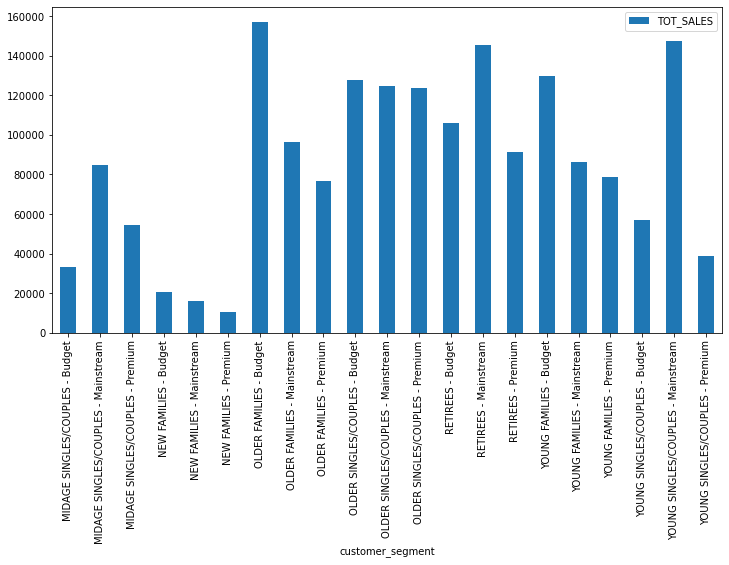

In [246]:
spending.plot(  kind='bar',
    figsize=(12,6))

## we see that the top 3 segments in tot_sales are :
#OLDER FAMILIES - Budget
#YOUNG SINGLES/COUPLES - Mainstream
#RETIREES - Mainstream

<AxesSubplot:>

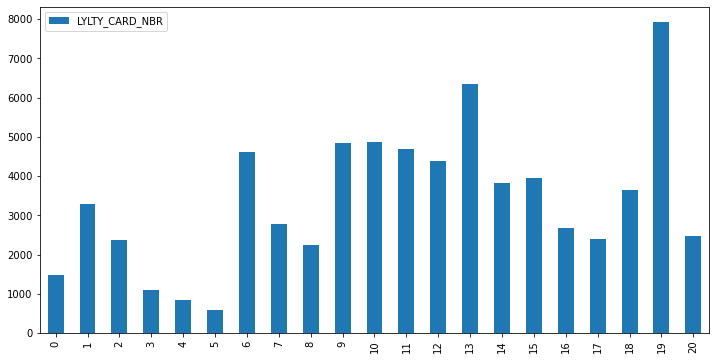

In [247]:
#Let's see if the higher sales are due to there being more customers who buy chips.
# lets see how many customers in each segment
n_cust = df.groupby("customer_segment")["LYLTY_CARD_NBR"].nunique().reset_index()
n_cust.plot(kind="bar",figsize=(12,6))

In [249]:
n_cust.sort_values(by="LYLTY_CARD_NBR",ascending=False)

,customer_segment,LYLTY_CARD_NBR
19,YOUNG SINGLES/COUPLES - Mainstream,7917
13,RETIREES - Mainstream,6358
10,OLDER SINGLES/COUPLES - Mainstream,4858
9,OLDER SINGLES/COUPLES - Budget,4849
11,OLDER SINGLES/COUPLES - Premium,4682
6,OLDER FAMILIES - Budget,4611
12,RETIREES - Budget,4385
15,YOUNG FAMILIES - Budget,3953
14,RETIREES - Premium,3812
18,YOUNG SINGLES/COUPLES - Budget,3647


we see that There are more Mainstream - young singles/couples and Mainstream - retirees who buy
chips. This contributes to there being more sales to these customer segments but 
this is not a major driver for the Budget - Older families segment.

In [252]:
#Higher sales may also be driven by more units of chips being bought per customer. 
units_per_customer = (
    df.groupby("customer_segment")
    .agg(
        total_units=('PROD_QTY', 'sum'),
        n_customers=('LYLTY_CARD_NBR', 'nunique')
    )
    .reset_index()
)

units_per_customer['avg_units_per_customer'] = (
    units_per_customer['total_units']
    / units_per_customer['n_customers']
)

units_per_customer.sort_values(by="avg_units_per_customer",ascending=False)

,customer_segment,total_units,n_customers,avg_units_per_customer
7,OLDER FAMILIES - Mainstream,25804,2788,9.255380
8,OLDER FAMILIES - Premium,20639,2232,9.246864
6,OLDER FAMILIES - Budget,41853,4611,9.076773
15,YOUNG FAMILIES - Budget,34482,3953,8.722995
17,YOUNG FAMILIES - Premium,20901,2398,8.716013
16,YOUNG FAMILIES - Mainstream,23194,2685,8.638361
9,OLDER SINGLES/COUPLES - Budget,32883,4849,6.781398
11,OLDER SINGLES/COUPLES - Premium,31693,4682,6.769116
10,OLDER SINGLES/COUPLES - Mainstream,32607,4858,6.712021
1,MIDAGE SINGLES/COUPLES - Mainstream,21213,3298,6.432080


Older families and young families in general buy more chips per customer

In [238]:
# now lets see the average chip price by customer segment
avg_price = df.groupby("customer_segment")["TOT_SALES"].mean().reset_index()
avg_price.columns = ["customer_segment","average_price"]
avg_price.sort_values(by="average_price",ascending=False)

,customer_segment,average_price
1,MIDAGE SINGLES/COUPLES - Mainstream,7.637156
19,YOUNG SINGLES/COUPLES - Mainstream,7.551279
14,RETIREES - Premium,7.461315
11,OLDER SINGLES/COUPLES - Premium,7.460085
12,RETIREES - Budget,7.445786
9,OLDER SINGLES/COUPLES - Budget,7.444305
8,OLDER FAMILIES - Premium,7.356329
4,NEW FAMILIES - Mainstream,7.313364
10,OLDER SINGLES/COUPLES - Mainstream,7.306049
15,YOUNG FAMILIES - Budget,7.302705


Mainstream midage and young singles and couples are more willing to pay more per 
packet of chips
As the difference in average price per unit isn't large, we can check if this difference is statistically different

In [265]:
dff = pd.merge(
    df,
    units_per_customer,
    on = "customer_segment",
    how = "left"
)

In [266]:
from scipy.stats import ttest_ind
t_stat,p_value = ttest_ind(
    dff[dff["customer_segment"]=="MIDAGE SINGLES/COUPLES - Mainstream"]["avg_units_per_customer"],
    dff[dff["customer_segment"]=="YOUNG SINGLES/COUPLES - Mainstream"]["avg_units_per_customer"],
    equal_var=False
    
)

In [267]:
print(t_stat)
print(p_value)

2.9220418391928723e+17
0.0


we think that MIDAGE SINGLES/COUPLES - Mainstream spend more by unit then YOUNG SINGLES/COUPLES - Mainstream

In [268]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,brand_name,year,month,month_year,day,day_of_week,customer_segment
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,175.0,Natural,2018,10,2018-10,17,Wednesday,YOUNG SINGLES/COUPLES - Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget,175.0,CCs,2019,5,2019-05,14,Tuesday,MIDAGE SINGLES/COUPLES - Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,170.0,Smiths,2019,5,2019-05,20,Monday,MIDAGE SINGLES/COUPLES - Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,175.0,Smiths,2018,8,2018-08,17,Friday,MIDAGE SINGLES/COUPLES - Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,150.0,Kettle,2018,8,2018-08,18,Saturday,MIDAGE SINGLES/COUPLES - Budget


Let's look at Mainstream - midage singles/couples as one of the most customer segments that returns heigh sales to gain some insights

In [308]:
target_segment = df[
    df["customer_segment"] == "MIDAGE SINGLES/COUPLES - Mainstream"
]

In [296]:
brand_pref = (
    target_segment.groupby("brand_name")
    .agg(
        total_sales=("TOT_SALES", "sum"),
        transactions=("TXN_ID", "nunique"),
        total_units=("PROD_QTY", "sum")
    )
    .reset_index()
    .sort_values("total_units", ascending=False)
)

brand_pref.head()

,brand_name,total_sales,transactions,total_units
12,Kettle,20231.8,2133,4085
18,Smiths,9374.9,1174,2251
15,Pringles,8177.0,1159,2210
6,Doritos,9014.9,1072,2042
21,Thins,4002.9,635,1213


we see that in this segment the top 3 most purshased are kettle,smith and pringles 
lets see to overal purshasing

In [297]:
overall_brand = (
    df.groupby("brand_name")["PROD_QTY"]
    .sum()
    .reset_index(name="overall_units")
    .sort_values("overall_units", ascending=False)
)
overall_brand.head()

,brand_name,overall_units
12,Kettle,79051
18,Smiths,51971
15,Pringles,48019
6,Doritos,42222
16,Red,30891


In [298]:
segment_brand = (
    target_segment.groupby("brand_name")["PROD_QTY"]
    .sum()
    .reset_index(name="segment_units")
    .sort_values("segment_units", ascending=False)
)
segment_brand.head()

,brand_name,segment_units
12,Kettle,4085
18,Smiths,2251
15,Pringles,2210
6,Doritos,2042
21,Thins,1213


In [299]:
brand_analysis = segment_brand.merge(
    overall_brand,
    on="brand_name"
)

brand_analysis["affinity"] = (
    brand_analysis["segment_units"]
    / brand_analysis["overall_units"]
)

brand_analysis.sort_values(
    "affinity",
    ascending=False
).head()

,brand_name,segment_units,overall_units,affinity
0,Kettle,4085,79051,0.051676
8,Twisties,932,18118,0.051441
7,Cobs,951,18571,0.051209
9,Tostitos,924,18134,0.050954
16,Infzns,302,6000,0.050333


wee see that this segment is especially attracted to Kettle products.

In [304]:
df["price_per_unit"] = df["TOT_SALES"] / df["PROD_QTY"]

In [305]:
brand_price = (
    df.groupby("brand_name")
    .agg(
        avg_price_per_unit=("price_per_unit", "mean")
    )
    .reset_index()
    .sort_values("avg_price_per_unit", ascending=False)
)

brand_price.head()

,brand_name,avg_price_per_unit
5,Dorito,6.366327
12,Kettle,4.936630
3,Cheezels,4.562829
23,Twisties,4.499439
6,Doritos,4.435271


wee see that kettle is likely a premuim-product and we can say that Mainstream midage singles/couples demonstrate stronger preference toward premium chip brands such as Kettle

now Let's also find out if our target segment tends to buy larger packs of chips.

In [309]:
target_avg = target_segment["PACK_SIZE"].mean()
target_avg

177.89869310500225

In [314]:
rest = df[df["customer_segment"] != "MIDAGE SINGLES/COUPLES - Mainstream"]
rest_avg = rest["PACK_SIZE"].mean()
rest_avg

175.47625251436477

we can say that The target segment shows a slightly higher average pack size (177.9g vs 175.5g), suggesting a marginal tendency toward purchasing larger packs compared to the broader population.

finaly we can say about Mainstream mid-age singles/couples that  exhibit slightly higher average pack size purchases compared to the rest of the population. While the difference is small, combined with higher price per unit and strong brand affinity, this suggests a tendency toward higher-value and potentially more premium snack consumption behavior